# Proximal Gradient Method (PGM)

We consider the composite convex minimization problem

$$
\min_x h(x) = f(x) + g(x),
$$

where $f$ is convex and $L$-smooth, $g$ is closed, proper, and convex, and $x_\star$ minimizes $h$. The initial point satisfies

$$
\|x_0-x_\star\|^2 \le R^2.
$$

Proximal gradient descent with fixed step size $1/L$ is

$$
y_{k+1}=x_k-\frac{1}{L}\nabla f(x_k),\qquad
x_{k+1}=\operatorname{prox}_{g/L}(y_{k+1}),
\qquad k=0,\ldots,N-1.
$$

The performance metric is

$$
h(x_N)-h(x_\star).
$$

The Block 1 numerical evidence identifies the candidate worst-case rate

$$
h(x_N)-h(x_\star) \le \frac{L R^2}{4N}.
$$


## Proof Statement


### Theorem

Assume $f$ is convex and $L$-smooth, $g$ is closed, proper, and convex, and $x_{\star}$ minimizes

$$
h(x)=f(x)+g(x).
$$

Let $x_{0}$ satisfy $\|x_{0}-x_{\star}\|^{2}\le R^{2}$, and let proximal gradient descent generate

$$
x_{k+1}=\operatorname{prox}_{g/L}\left(x_{k}-\frac{1}{L}\nabla f(x_{k})\right),
\qquad k=0,\ldots,N-1.
$$

Then

$$
h(x_{N})-h(x_{\star})\le \frac{L R^{2}}{4N}.
$$

For $1\le k<N$, define

$$
\begin{aligned}
V_{k}={}&
\frac{k+1}{2N-k}\bigl(f(x_{k})-f(x_{\star})\bigr)
+\frac{k}{2N-k}\bigl(g(x_{k})-g(x_{\star})\bigr)
-\frac{L}{4N}\|x_{0}-x_{\star}\|^{2} \\
&+\frac{L(N-k)}{(2N-k)^{2}}\|x_{k}-x_{\star}\|^{2}
-\frac{1}{2N-k}\left\langle x_{k}-x_{\star},\nabla f(x_{k})\right\rangle
+\frac{1}{2L(2N-k)}\|\nabla f(x_{k})-\nabla f(x_{\star})\|^{2}.
\end{aligned}
$$

The terminal expression is

$$
V_{N}=h(x_{N})-h(x_{\star})-\frac{L}{4N}\|x_{0}-x_{\star}\|^{2}.
$$


### Proof outline

For $f$, use the smooth-convex interpolation residual

$$
I_{f}(u,v)=f(v)-f(u)+\langle \nabla f(v),u-v\rangle
+\frac{1}{2L}\|\nabla f(u)-\nabla f(v)\|^{2}\le 0.
$$

For $g$, use the convex interpolation residual

$$
I_{g}(u,v)=g(v)-g(u)+\langle s_{v},u-v\rangle\le 0,
\qquad s_{v}\in\partial g(v).
$$

The proximal update gives $s_{x_{i}}=-\nabla f(x_{i-1})$ for $i\ge 1$. Define the nonnegative square certificate $S_{i}=S_{i}^{(1)}+S_{i}^{(2)}+S_{i}^{(3)}$, where

$$
S_{i}^{(1)}=
\frac{N}{(2N+1-i)(2N-i)L}
\left\|\frac{i}{2N}\nabla f(x_{i})
+\frac{2N-i}{2N}\nabla f(x_{i-1})
-\nabla f(x_{\star})\right\|^{2},
$$

$$
S_{i}^{(2)}=
\left(
\frac{i-1}{2N-i}\frac{2N+2}{2N+1}
+\frac{1}{(2N-i)^{2}}\frac{2N}{2N+1}
\right)
\frac{1}{2L}
\left\|\nabla f(x_{i-1})+s_{x_{i}}
-\frac{L}{2N+1-i}(x_{i-1}-x_{\star})\right\|^{2},
$$

and

$$
S_{i}^{(3)}=
\frac{i}{2N+1-i}\frac{2N}{2N+1}\frac{1}{2L}
\left\|
\frac{2N+1}{2N}\bigl(\nabla f(x_{i})+s_{x_{i}}\bigr)
-\frac{1}{2N}\bigl(\nabla f(x_{i-1})+s_{x_{i}}\bigr)
-\frac{L}{2N-i}(x_{i}-x_{\star})
\right\|^{2}.
$$

The base identity is

$$
\begin{aligned}
V_{1}={}&
\frac{1}{2N}I_{f}(x_{\star},x_{0})
+\frac{1}{2N}I_{f}(x_{0},x_{1})
+\left(\frac{2}{2N-1}-\frac{1}{2N}\right)I_{f}(x_{\star},x_{1})\\
&+\frac{1}{2N-1}I_{g}(x_{\star},x_{1})-S_{1}.
\end{aligned}
$$

For $1\le k<N-1$, the step identity is

$$
\begin{aligned}
V_{k+1}-V_{k}={}&
\frac{k+1}{2N-k}I_{f}(x_{k},x_{k+1})
+\left(\frac{k+2}{2N-k-1}-\frac{k+1}{2N-k}\right)I_{f}(x_{\star},x_{k+1})\\
&+\frac{k}{2N-k}I_{g}(x_{k},x_{k+1})
+\frac{2N}{(2N-k)(2N-k-1)}I_{g}(x_{\star},x_{k+1})
-S_{k+1}.
\end{aligned}
$$

All interpolation residuals are nonpositive and all $S_{i}$ are nonnegative, so $V_{1}\le 0$ and $V_{k+1}\le V_{k}$. Therefore $V_{N}\le 0$, and the boundary identity gives

$$
h(x_{N})-h(x_{\star})-\frac{L}{4N}\|x_{0}-x_{\star}\|^{2}=V_{N}\le 0.
$$

Using $\|x_{0}-x_{\star}\|^{2}\le R^{2}$ proves the stated guarantee.


## Imports


In [1]:
import importlib.util
import json
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "pepflow").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pepflow as pf  # noqa: E402
import sympy as sp  # noqa: E402

## Function and Parameters


In [2]:
L = pf.Parameter("L")
R = pf.Parameter("R")
f = pf.SmoothConvexFunction(is_basis=True, tags=["f"], L=L)
g = pf.ConvexFunction(is_basis=True, tags=["g"])
h = (f + g).add_tag("h")

## PGM PEP Setup


In [3]:
def make_ctx_pgm(ctx_name: str, N, **kwargs) -> pf.PEPContext:
    ctx = pf.PEPContext(ctx_name).set_as_current()
    x = pf.Vector(is_basis=True, tags=["x_0"])
    h.set_stationary_point("x_star")

    for k in range(int(N)):
        y = x - (1 / L) * f.grad(x)
        y.add_tag(f"y_{k + 1}")
        x = g.prox(y, 1 / L, tag=f"x_{k + 1}")

    return ctx


def get_pep_setup(N, params):
    ctx = make_ctx_pgm(f"ctx_{N}", N)
    pb = pf.PEPBuilder(ctx)
    pb.add_initial_constraint(
        ((ctx["x_0"] - ctx["x_star"]) ** 2).le(R**2, name="initial_condition")
    )
    pb.set_performance_metric(h(ctx[f"x_{N}"]) - h(ctx["x_star"]))
    return ctx, pb, f

## Numerical Evidence


N=1: PEP=0.2499847657, L R^2/(4N)=0.2500000000, diff=-1.52e-05
N=2: PEP=0.1250001922, L R^2/(4N)=0.1250000000, diff=+1.92e-07
N=3: PEP=0.0833279610, L R^2/(4N)=0.0833333333, diff=-5.37e-06
N=4: PEP=0.0624998898, L R^2/(4N)=0.0625000000, diff=-1.10e-07
N=5: PEP=0.0499949146, L R^2/(4N)=0.0500000000, diff=-5.09e-06
N=6: PEP=0.0416633837, L R^2/(4N)=0.0416666667, diff=-3.28e-06
N=7: PEP=0.0357111009, L R^2/(4N)=0.0357142857, diff=-3.18e-06


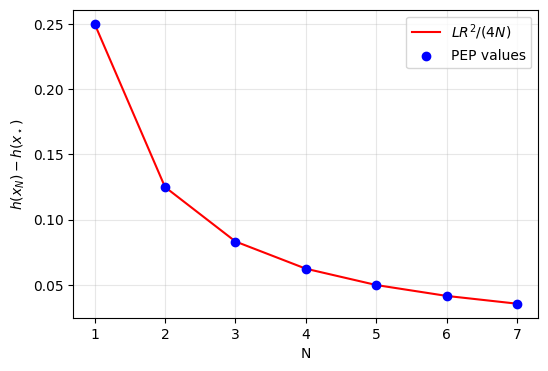

In [4]:
sweep_results = [
    {"N": 1, "opt_value": 0.24998476565221175},
    {"N": 2, "opt_value": 0.1250001921749428},
    {"N": 3, "opt_value": 0.08332796104103286},
    {"N": 4, "opt_value": 0.06249988977748486},
    {"N": 5, "opt_value": 0.049994914582988104},
    {"N": 6, "opt_value": 0.041663383690341255},
    {"N": 7, "opt_value": 0.03571110091014559},
]
iters = np.array([r["N"] for r in sweep_results], dtype=float)
opt_values = np.array([r["opt_value"] for r in sweep_results], dtype=float)
rate_values = 1 / (4 * iters)

for n, value, rate in zip(iters.astype(int), opt_values, rate_values):
    print(f"N={n}: PEP={value:.10f}, L R^2/(4N)={rate:.10f}, diff={value - rate:+.2e}")

plt.figure(figsize=(6, 4))
plt.plot(iters, rate_values, "r-", label=r"$L R^2/(4N)$")
plt.scatter(iters, opt_values, color="blue", zorder=3, label="PEP values")
plt.xlabel("N")
plt.ylabel(r"$h(x_N)-h(x_\star)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Block 1 Summary

With $L=R=1$, the PEP values agree with $1/(4N)$ up to solver tolerance. The working conjecture for later proof blocks is

$$
h(x_N)-h(x_\star) \le \frac{L R^2}{4N}.
$$


## Dense and Relaxed Proof Solves

Block 2 uses the verification horizon `N_verify = 4`. The dense certificate is stored in `state/pgm_dense.json`; the relaxed certificate is stored in `state/pgm_relaxed.json`; and the durable proof state is stored in `state/pgm_b2.json`.


In [5]:
b2 = json.loads((REPO_ROOT / "examples_peppy/pgm/state/pgm_b2.json").read_text())
print("dense opt:", f"{b2['dense_opt_value']:.10f}")
print("relaxed opt:", f"{b2['opt_value']:.10f}")
print("target:", f"{1 / (4 * b2['N_verify']):.10f}")
print("proof valid:", b2["proof_valid"])
print("basis vectors:", b2["basis_vectors"])

dense opt: 0.0624998898
relaxed opt: 0.0625082451
target: 0.0625000000
proof valid: True
basis vectors: ['x_0', 'x_star', 'grad_f(x_star)', 'grad_f(x_0)', 'grad_g(x_1)', 'grad_f(x_1)', 'grad_g(x_2)', 'grad_f(x_2)', 'grad_g(x_3)', 'grad_f(x_3)', 'grad_g(x_4)', 'grad_f(x_4)']


## Sparse Certificate Pattern


In [6]:
print("active f lambda entries")
for ri, ci, value in b2["active_lambda_f_entries"]:
    print(f"  lambda_f({ri}, {ci}) = {value}")

print("\nactive g gamma entries")
for ri, ci, value in b2["active_gamma_g_entries"]:
    print(f"  gamma_g({ri}, {ci}) = {value}")

active f lambda entries
  lambda_f(x_0, x_1) = 1/8
  lambda_f(x_1, x_2) = 2/7
  lambda_f(x_2, x_3) = 1/2
  lambda_f(x_3, x_4) = 4/5
  lambda_f(x_star, x_0) = 1/8
  lambda_f(x_star, x_1) = 9/56
  lambda_f(x_star, x_2) = 3/14
  lambda_f(x_star, x_3) = 3/10
  lambda_f(x_star, x_4) = 1/5

active g gamma entries
  gamma_g(x_1, x_2) = 1/7
  gamma_g(x_2, x_3) = 1/3
  gamma_g(x_3, x_4) = 3/5
  gamma_g(x_star, x_1) = 1/7
  gamma_g(x_star, x_2) = 4/21
  gamma_g(x_star, x_3) = 4/15
  gamma_g(x_star, x_4) = 2/5


## Closed-Form Lambda and Gamma Verification


In [7]:
N_int = b2["N_verify"]


def tag_to_index(tag, N):
    return N + 1 if tag == "x_star" else int(tag.split("_")[1])


def lamb(ri, ci, N=N_int):
    i = tag_to_index(ri, N)
    j = tag_to_index(ci, N)
    if i == N + 1:
        if j == 0:
            return lamb("x_0", "x_1", N)
        if j < N:
            return lamb(f"x_{j}", f"x_{j + 1}", N) - lamb(f"x_{j - 1}", f"x_{j}", N)
        if j == N:
            return sp.S(1) - lamb(f"x_{N - 1}", f"x_{N}", N)
    if i < N and i + 1 == j:
        return sp.Rational(j, 2 * N + 1 - j)
    return sp.S(0)


def gamm(ri, ci, N=N_int):
    i = tag_to_index(ri, N)
    j = tag_to_index(ci, N)
    if i == N + 1 and 1 <= j <= N:
        return sp.Rational(2 * N, (2 * N + 1 - j) * (2 * N - j))
    if i < N and i + 1 == j:
        return sp.Rational(j - 1, 2 * N + 1 - j)
    return sp.S(0)


N_int = b2["N_verify"]
lambda_cand = pf.pprint_labeled_matrix(
    lamb, b2["lambda_row_names"], b2["lambda_col_names"], return_matrix=True
)
gamma_cand = pf.pprint_labeled_matrix(
    gamm, b2["gamma_row_names"], b2["gamma_col_names"], return_matrix=True
)
print("lambda max residual:", b2["lambda_max_residual"])
print("gamma max residual:", b2["gamma_max_residual"])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

lambda max residual: 0.00010079152359090959
gamma max residual: 0.0001115631254652305


## S Decomposition and Proof Identity


In [8]:
print("S decomposition: direct sum of three square families from the PGM certificate.")
print("S max residual:", b2["S_max_residual"])
print("proof matrix max residual:", b2["proof_matrix_max_residual"])
print("proof function-coordinate max residual:", b2["proof_func_max_residual"])
print("Proof valid:", b2["proof_valid"])

S decomposition: direct sum of three square families from the PGM certificate.
S max residual: 0.00011069815018049933
proof matrix max residual: 1.1102230246251565e-16
proof function-coordinate max residual: 5.551115123125783e-17
Proof valid: True


## Partial-Sum Lyapunov Construction and Rank Profile

Using the Block 2 certificate, define partial sums by first adding the boundary interpolation term for $f(x_\star,x_0)$. For each step $i=1,\ldots,N$, use

$$
V_i - V_{i-1}
= \lambda_{i-1,i} I_f(x_{i-1},x_i)
  \lambda_{\star,i} I_f(x_\star,x_i)
  \gamma_{i-1,i} I_g(x_{i-1},x_i)
  \gamma_{\star,i} I_g(x_\star,x_i)
  - S_i,
$$

where $\gamma_{0,1}=0$ and $S_i$ is the corresponding direct three-square piece of the PGM Gram certificate from Block 2. At `N_verify = 4`, this gives rank profile `[0, 4, 4, 4, 1]`: the interior rank is constant, and the final rank-one term is the terminal boundary residual.


In [9]:
b3 = json.loads((REPO_ROOT / "examples_peppy/pgm/state/pgm_b3.json").read_text())
N_int = b3["N_verify"]
params_sp = {"L": sp.S(1), "R": sp.S(1)}

spec = importlib.util.spec_from_file_location(
    "pgm_setup", str(REPO_ROOT / "examples_peppy/pgm/pgm_setup.py")
)
if spec is None or spec.loader is None:
    raise ImportError("Cannot load pgm_setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

ctx_lyap, pb_lyap, _ = setup.get_pep_setup(sp.S(N_int), params_sp)
pb_lyap.set_relaxed_constraints(b3["relaxed_constraints"])
pb_lyap.solve(resolve_parameters=params_sp)
pm_lyap = pf.ExpressionManager(ctx_lyap, resolve_parameters=params_sp)

L = setup.L
f = setup.f
g = setup.g
x = ctx_lyap.tracked_point(f)
x_star = ctx_lyap["x_star"]
rank_tolerance = b3["rank_tolerance"]

C:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\function.py:167: UserWarning:


C:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\function.py:167: UserWarning:




In [10]:
def tag_to_index_b3(tag, N):
    return N + 1 if tag == "x_star" else int(tag.split("_")[1])


def lamb(ri, ci, N=N_int):
    i = tag_to_index_b3(ri, N)
    j = tag_to_index_b3(ci, N)
    if i == N + 1:
        if j == 0:
            return lamb("x_0", "x_1", N)
        if j < N:
            return lamb(f"x_{j}", f"x_{j + 1}", N) - lamb(f"x_{j - 1}", f"x_{j}", N)
        if j == N:
            return sp.S(1) - lamb(f"x_{N - 1}", f"x_{N}", N)
    if i < N and i + 1 == j:
        return sp.Rational(j, 2 * N + 1 - j)
    return sp.S(0)


def gamm(ri, ci, N=N_int):
    i = tag_to_index_b3(ri, N)
    j = tag_to_index_b3(ci, N)
    if i == N + 1 and 1 <= j <= N:
        return sp.Rational(2 * N, (2 * N + 1 - j) * (2 * N - j))
    if i < N and i + 1 == j:
        return sp.Rational(j - 1, 2 * N + 1 - j)
    return sp.S(0)


def S_piece(i):
    return (
        sp.Rational(N_int, (2 * N_int + 1 - i) * (2 * N_int - i))
        / L
        * (
            sp.Rational(i, 2 * N_int) * f.grad(x[i])
            + sp.Rational(2 * N_int - i, 2 * N_int) * f.grad(x[i - 1])
            - f.grad(x_star)
        )
        ** 2
        + (
            sp.Rational(i - 1, 2 * N_int - i)
            * sp.Rational(2 * N_int + 2, 2 * N_int + 1)
            + sp.Rational(1, (2 * N_int - i) ** 2)
            * sp.Rational(2 * N_int, 2 * N_int + 1)
        )
        / (2 * L)
        * (
            f.grad(x[i - 1])
            + g.grad(x[i])
            - L * sp.Rational(1, 2 * N_int + 1 - i) * (x[i - 1] - x_star)
        )
        ** 2
        + sp.Rational(i, 2 * N_int + 1 - i)
        * sp.Rational(2 * N_int, 2 * N_int + 1)
        / (2 * L)
        * (
            sp.Rational(2 * N_int + 1, 2 * N_int) * (f.grad(x[i]) + g.grad(x[i]))
            - sp.Rational(1, 2 * N_int) * (f.grad(x[i - 1]) + g.grad(x[i]))
            - L * sp.Rational(1, 2 * N_int - i) * (x[i] - x_star)
        )
        ** 2
    )

In [11]:
lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
partial_sum += lamb("x_star", "x_0") * f.interp_ineq("x_star", "x_0")

for step in range(N_int):
    i = step + 1
    partial_sum -= S_piece(i)
    partial_sum += lamb(f"x_{step}", f"x_{i}") * f.interp_ineq(f"x_{step}", f"x_{i}")
    partial_sum += lamb("x_star", f"x_{i}") * f.interp_ineq("x_star", f"x_{i}")
    gamma_consecutive = gamm(f"x_{step}", f"x_{i}")
    if gamma_consecutive != 0:
        partial_sum += gamma_consecutive * g.interp_ineq(f"x_{step}", f"x_{i}")
    partial_sum += gamm("x_star", f"x_{i}") * g.interp_ineq("x_star", f"x_{i}")
    lyap.append(partial_sum)

ranks = []
for k, Vk in enumerate(lyap):
    matrix = pm_lyap.eval_scalar(Vk).inner_prod_coords.astype(float)
    rank = int(np.linalg.matrix_rank(matrix, tol=rank_tolerance))
    ranks.append(rank)
    print(f"rank V_{k}: {rank}")
    if k == 0:
        print()

print("Interior rank is constant:", len(set(ranks[1:N_int])) == 1)

rank V_0: 0

rank V_1: 4
rank V_2: 4
rank V_3: 4
rank V_4: 1
Interior rank is constant: True


In [12]:
M_final = pm_lyap.eval_scalar(lyap[N_int]).inner_prod_coords.astype(float)
rank_final = int(np.linalg.matrix_rank(M_final, tol=rank_tolerance))
print(f"lyap[{N_int}] rank:", rank_final)
print("Coverage check: lyap[N] is rank one, matching the terminal boundary residual.")

lyap[4] rank: 1
Coverage check: lyap[N] is rank one, matching the terminal boundary residual.


## Identify the vectors composing the Lyapunov function

Block 4 starts from the Block 3 partial sums and searches for interpretable vectors that span the rank-four interior Lyapunov terms.


In [13]:
from pepflow.lyapunov_utils import (
    find_symmetric_coefficient_matrix,
    select_independent_subset,
    vectors_in_column_space,
)

b4 = json.loads((REPO_ROOT / "examples_peppy/pgm/state/pgm_b4.json").read_text())
print("stored rank profile:", b4["rank_profile"])
print("coefficient residuals:", b4["coeff_residuals"])

stored rank profile: [0, 4, 4, 4, 1]
coefficient residuals: {'1': 6.938893903907228e-17, '2': 4.163336342344337e-17, '3': 1.0408340855860843e-16, '4': 0.0}


### Candidate-vector scan

Candidates include point-to-solution gaps, smooth gradients, gradient differences against the solution, proximal optimality residuals, and stationarity residuals. Duplicate and zero candidates are skipped before testing column-space membership.


In [14]:
def candidate_coord(v):
    return tuple(np.round(pm_lyap.eval_vector(v).coords.astype(float), 10))


candidate_pairs = []
seen_candidates = set()


def add_candidate(label, v):
    try:
        coords = candidate_coord(v)
        if np.linalg.norm(coords) < 1e-9 or coords in seen_candidates:
            return
        seen_candidates.add(coords)
        candidate_pairs.append((label, v))
    except Exception:
        return


add_candidate("x_0 - x_star", ctx_lyap["x_0"] - x_star)
add_candidate("grad_f(x_star)", f.grad(x_star))
for i in range(N_int + 1):
    add_candidate(f"x_{i} - x_star", ctx_lyap[f"x_{i}"] - x_star)
    add_candidate(f"grad_f(x_{i})", f.grad(ctx_lyap[f"x_{i}"]))
    add_candidate(
        f"grad_f(x_{i}) - grad_f(x_star)",
        f.grad(ctx_lyap[f"x_{i}"]) - f.grad(x_star),
    )
for i in range(1, N_int + 1):
    add_candidate(f"grad_g(x_{i})", g.grad(ctx_lyap[f"x_{i}"]))
    add_candidate(
        f"grad_f(x_{i}) + grad_g(x_{i})",
        f.grad(ctx_lyap[f"x_{i}"]) + g.grad(ctx_lyap[f"x_{i}"]),
    )
    add_candidate(
        f"grad_f(x_{i - 1}) + grad_g(x_{i})",
        f.grad(ctx_lyap[f"x_{i - 1}"]) + g.grad(ctx_lyap[f"x_{i}"]),
    )

print("candidate count:", len(candidate_pairs))

candidate count: 28


In [15]:
for k in range(1, N_int + 1):
    in_col = vectors_in_column_space(
        lyap[k],
        [v for _, v in candidate_pairs],
        pep_context=ctx_lyap,
        resolve_parameters=params_sp,
        rtol=1e-4,
        atol=1e-4,
    )
    labels = [label for label, v in candidate_pairs if any(v is w for w in in_col)]
    print(f"V_{k} column-space candidates:")
    for label in labels:
        print(f"   {label}")

V_1 column-space candidates:
   x_0 - x_star
   grad_f(x_star)
   x_1 - x_star
   grad_f(x_1)
   grad_f(x_1) - grad_f(x_star)
   grad_f(x_0) + grad_g(x_1)
V_2 column-space candidates:
   x_0 - x_star
   grad_f(x_star)
   x_2 - x_star
   grad_f(x_2)
   grad_f(x_2) - grad_f(x_star)


V_3 column-space candidates:


   x_0 - x_star
   grad_f(x_star)
   x_3 - x_star
   grad_f(x_3)
   grad_f(x_3) - grad_f(x_star)
V_4 column-space candidates:
   x_0 - x_star


### Selected basis pattern

The interior template is

$$
\mathcal B_k =
\left[
x_0-x_\star,\;
x_k-x_\star,\;
\nabla f(x_k),\;
\nabla f(x_k)-\nabla f(x_\star)
\right],
\qquad 1\le k<N.
$$

The terminal boundary term is rank one with basis $[x_0-x_\star]$.


In [16]:
def V_k_basis(k):
    if k == 0:
        return []
    if k == N_int:
        return [ctx_lyap["x_0"] - x_star]
    return [
        ctx_lyap["x_0"] - x_star,
        ctx_lyap[f"x_{k}"] - x_star,
        f.grad(ctx_lyap[f"x_{k}"]),
        f.grad(ctx_lyap[f"x_{k}"]) - f.grad(x_star),
    ]


def V_k_basis_labels(k):
    if k == 0:
        return []
    if k == N_int:
        return ["x_0 - x_star"]
    return [
        "x_0 - x_star",
        f"x_{k} - x_star",
        f"grad_f(x_{k})",
        f"grad_f(x_{k}) - grad_f(x_star)",
    ]


for k in range(1, N_int + 1):
    basis = V_k_basis(k)
    selected, _ = select_independent_subset(
        basis,
        pep_context=ctx_lyap,
        resolve_parameters=params_sp,
        tol=1e-7,
    )
    print(f"k={k}: rank {len(selected)} basis {V_k_basis_labels(k)}")

k=1: rank 4 basis ['x_0 - x_star', 'x_1 - x_star', 'grad_f(x_1)', 'grad_f(x_1) - grad_f(x_star)']
k=2: rank 4 basis ['x_0 - x_star', 'x_2 - x_star', 'grad_f(x_2)', 'grad_f(x_2) - grad_f(x_star)']
k=3: rank 4 basis ['x_0 - x_star', 'x_3 - x_star', 'grad_f(x_3)', 'grad_f(x_3) - grad_f(x_star)']
k=4: rank 1 basis ['x_0 - x_star']


### Coefficient matrices

The displayed matrices use the selected basis order above. The accompanying function pattern is the coefficient of the function-value part of each `V_k`.


In [17]:
def coeff_pattern(k, N):
    if k == N:
        return [[-sp.Rational(1, 4 * N)]], {
            f"f(x_{N})-f(x_star)": sp.S(1),
            f"g(x_{N})-g(x_star)": sp.S(1),
        }
    C = [
        [-sp.Rational(1, 4 * N), sp.S(0), sp.S(0), sp.S(0)],
        [
            sp.S(0),
            sp.Rational(N - k, (2 * N - k) ** 2),
            -sp.Rational(1, 2 * (2 * N - k)),
            sp.S(0),
        ],
        [sp.S(0), -sp.Rational(1, 2 * (2 * N - k)), sp.S(0), sp.S(0)],
        [sp.S(0), sp.S(0), sp.S(0), sp.Rational(1, 2 * (2 * N - k))],
    ]
    return C, {
        f"f(x_{k})-f(x_star)": sp.Rational(k + 1, 2 * N - k),
        f"g(x_{k})-g(x_star)": sp.Rational(k, 2 * N - k),
    }


for k in range(1, N_int + 1):
    basis = V_k_basis(k)
    labels = V_k_basis_labels(k)
    C = find_symmetric_coefficient_matrix(
        lyap[k],
        basis,
        pep_context=ctx_lyap,
        resolve_parameters=params_sp,
        span_tol=1e-5,
    )
    C_formula, func_pattern = coeff_pattern(k, N_int)
    C_formula_np = np.array(C_formula, dtype=float)
    residual = np.max(np.abs(C - C_formula_np))
    print(f"k={k}: formula residual {residual:.3e}; function {func_pattern}")
    pf.pprint_labeled_matrix(C, labels, labels, precision=6)

k=1: formula residual 6.939e-17; function {'f(x_1)-f(x_star)': 2/7, 'g(x_1)-g(x_star)': 1/7}


<IPython.core.display.Math object>

k=2: formula residual 4.163e-17; function {'f(x_2)-f(x_star)': 1/2, 'g(x_2)-g(x_star)': 1/3}


<IPython.core.display.Math object>

k=3: formula residual 1.041e-16; function {'f(x_3)-f(x_star)': 4/5, 'g(x_3)-g(x_star)': 3/5}

<IPython.core.display.Math object>

k=4: formula residual 0.000e+00; function {'f(x_4)-f(x_star)': 1, 'g(x_4)-g(x_star)': 1}


<IPython.core.display.Math object>

### Block 4 conclusion

For $1\le k<N$, the current closed-form candidate is the sum of the function-value term

$$
\frac{k+1}{2N-k}\bigl(f(x_k)-f(x_\star)\bigr)
+ \frac{k}{2N-k}\bigl(g(x_k)-g(x_\star)\bigr)
$$

and the quadratic form in the selected basis $\mathcal B_k$ with the coefficient pattern shown above. Block 5 will symbolically verify the step, base, and boundary identities.


## Coefficient Extraction and Closed-Form $V_k$

Block 4 identified the coefficient pattern at $L=1$. Restoring the scale of $L$ gives, for $1\le k<N$,

$$
\begin{aligned}
V_{k}={}&
\frac{k+1}{2N-k}\bigl(f(x_{k})-f(x_{\star})\bigr)
+\frac{k}{2N-k}\bigl(g(x_{k})-g(x_{\star})\bigr)
-\frac{L}{4N}\|x_{0}-x_{\star}\|^{2} \\
&+\frac{L(N-k)}{(2N-k)^{2}}\|x_{k}-x_{\star}\|^{2}
-\frac{1}{2N-k}\langle x_{k}-x_{\star},\nabla f(x_{k})\rangle
+\frac{1}{2L(2N-k)}\|\nabla f(x_{k})-\nabla f(x_{\star})\|^{2}.
\end{aligned}
$$

The terminal expression is $V_{N}=h(x_{N})-h(x_{\star})-\frac{L}{4N}\|x_{0}-x_{\star}\|^{2}$.


In [18]:
b5 = json.loads((REPO_ROOT / "examples_peppy/pgm/state/pgm_b5.json").read_text())
print(b5["V_formula"])
pf.pprint_str(b5["S_formula"])

For 1 <= k < N: V_k = (k+1)/(2N-k)(f_k-f_*) + k/(2N-k)(g_k-g_*) - L/(4N)||x_0-x_*||^2 + L(N-k)/(2N-k)^2||x_k-x_*||^2 - 1/(2N-k)<x_k-x_*, grad f(x_k)> + 1/(2L(2N-k))||grad f(x_k)-grad f(x_*)||^2. V_N = h(x_N)-h(x_*) - L/(4N)||x_0-x_*||^2.


<IPython.core.display.Math object>

## Symbolic Step Recursion Verification


For $1\le k<N-1$, this cell verifies

$$
\mathrm{LHS}-\mathrm{RHS}
=
(V_{k+1}-V_{k})
-\left[
\frac{k+1}{2N-k}I_{f}(x_{k},x_{k+1})
+\left(\frac{k+2}{2N-k-1}-\frac{k+1}{2N-k}\right)I_{f}(x_{\star},x_{k+1})
+\frac{k}{2N-k}I_{g}(x_{k},x_{k+1})
+\frac{2N}{(2N-k)(2N-k-1)}I_{g}(x_{\star},x_{k+1})
-S_{k+1}
\right].
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.


In [19]:
def _register_function_values(funcs, points):
    for func in funcs:
        for point in points:
            func(point)


def _simplified_residual(diff, ctx, resolve_parameters):
    pm = pf.ExpressionManager(ctx, resolve_parameters=resolve_parameters)
    evaluated = pm.eval_scalar(diff)
    matrix = sp.Matrix(evaluated.inner_prod_coords).applyfunc(
        lambda expr: sp.factor(sp.cancel(sp.simplify(sp.nsimplify(expr))))
    )
    funcs = sp.Matrix(evaluated.func_coords).applyfunc(
        lambda expr: sp.factor(sp.cancel(sp.simplify(sp.nsimplify(expr))))
    )
    return matrix, funcs


def _V_expr(x_anchor, x_star, x_cur, idx, N_param, L_param, f_obj, g_obj):
    denom = 2 * N_param - idx
    basis = [
        x_anchor - x_star,
        x_cur - x_star,
        f_obj.grad(x_cur),
        f_obj.grad(x_cur) - f_obj.grad(x_star),
    ]
    C = [
        [-L_param / (4 * N_param), sp.S(0), sp.S(0), sp.S(0)],
        [
            sp.S(0),
            L_param * (N_param - idx) / denom**2,
            -sp.Rational(1, 2) / denom,
            sp.S(0),
        ],
        [sp.S(0), -sp.Rational(1, 2) / denom, sp.S(0), sp.S(0)],
        [sp.S(0), sp.S(0), sp.S(0), sp.Rational(1, 2) / (L_param * denom)],
    ]
    quadratic = pf.Scalar.zero()
    for row in range(4):
        for col in range(4):
            if C[row][col] != 0:
                quadratic += C[row][col] * (basis[row] * basis[col])
    return (
        (idx + 1) / denom * (f_obj(x_cur) - f_obj(x_star))
        + idx / denom * (g_obj(x_cur) - g_obj(x_star))
        + quadratic
    )


def _S_piece(i, x_prev, x_cur, x_star, N_param, L_param, f_obj, g_obj):
    return (
        N_param
        / ((2 * N_param + 1 - i) * (2 * N_param - i) * L_param)
        * (
            i / (2 * N_param) * f_obj.grad(x_cur)
            + (2 * N_param - i) / (2 * N_param) * f_obj.grad(x_prev)
            - f_obj.grad(x_star)
        )
        ** 2
        + (
            (i - 1) / (2 * N_param - i) * (2 * N_param + 2) / (2 * N_param + 1)
            + 1 / (2 * N_param - i) ** 2 * 2 * N_param / (2 * N_param + 1)
        )
        / (2 * L_param)
        * (
            f_obj.grad(x_prev)
            + g_obj.grad(x_cur)
            - L_param / (2 * N_param + 1 - i) * (x_prev - x_star)
        )
        ** 2
        + i
        / (2 * N_param + 1 - i)
        * 2
        * N_param
        / (2 * N_param + 1)
        / (2 * L_param)
        * (
            (2 * N_param + 1) / (2 * N_param) * (f_obj.grad(x_cur) + g_obj.grad(x_cur))
            - 1 / (2 * N_param) * (f_obj.grad(x_prev) + g_obj.grad(x_cur))
            - L_param / (2 * N_param - i) * (x_cur - x_star)
        )
        ** 2
    )


def _print_residual_check(matrix, funcs):
    matrix_zero = matrix == sp.zeros(*matrix.shape)
    funcs_zero = funcs == sp.zeros(*funcs.shape)
    print("inner-product residual zero:", matrix_zero)
    print("function-coordinate residual zero:", funcs_zero)
    return matrix_zero and funcs_zero

In [20]:
ctx_step = pf.PEPContext("pgm_step_symbolic").set_as_current()
L_step = pf.Parameter("L")
k_step = pf.Parameter("k")
N_step = pf.Parameter("N")
f_step = pf.SmoothConvexFunction(is_basis=True, tags=["f_{step}"], L=L_step)
g_step = pf.ConvexFunction(is_basis=True, tags=["g_{step}"])
h_step = (f_step + g_step).add_tag("h_{step}")
h_step.set_stationary_point("x_star")

xs_step = ctx_step["x_star"]
x0_step = pf.Vector(is_basis=True, tags=["x_0"])
xk_step = pf.Vector(is_basis=True, tags=["x_k"])
xk1_step = g_step.prox(
    xk_step - (1 / L_step) * f_step.grad(xk_step),
    1 / L_step,
    tag="x_{k+1}",
)
xk2_step = g_step.prox(
    xk1_step - (1 / L_step) * f_step.grad(xk1_step),
    1 / L_step,
    tag="x_{k+2}",
)
_register_function_values(
    [f_step, g_step],
    [xs_step, x0_step, xk_step, xk1_step, xk2_step],
)

lhs_step = _V_expr(
    x0_step, xs_step, xk1_step, k_step + 1, N_step, L_step, f_step, g_step
) - _V_expr(x0_step, xs_step, xk_step, k_step, N_step, L_step, f_step, g_step)
rhs_step = (
    (k_step + 1) / (2 * N_step - k_step) * f_step.interp_ineq("x_k", "x_{k+1}")
    + ((k_step + 2) / (2 * N_step - k_step - 1) - (k_step + 1) / (2 * N_step - k_step))
    * f_step.interp_ineq("x_star", "x_{k+1}")
    + k_step / (2 * N_step - k_step) * g_step.interp_ineq("x_k", "x_{k+1}")
    + 2
    * N_step
    / ((2 * N_step - k_step) * (2 * N_step - k_step - 1))
    * g_step.interp_ineq("x_star", "x_{k+1}")
    - _S_piece(k_step + 1, xk_step, xk1_step, xs_step, N_step, L_step, f_step, g_step)
)
diff_step = lhs_step - rhs_step
k_symbol, N_symbol, L_symbol = sp.symbols("k N L", positive=True)
step_matrix, step_funcs = _simplified_residual(
    diff_step,
    ctx_step,
    {"k": k_symbol, "N": N_symbol, "L": L_symbol},
)
pf.pprint_labeled_matrix(
    np.array(step_matrix.tolist(), dtype=object),
    [str(v) for v in ctx_step.basis_vectors()],
    [str(v) for v in ctx_step.basis_vectors()],
    precision=None,
)
print("function-coordinate residual:", list(step_funcs))
step_identity_zero = _print_residual_check(step_matrix, step_funcs)

<IPython.core.display.Math object>

function-coordinate residual: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
inner-product residual zero: True
function-coordinate residual zero: True


## Base Case and Boundary Symbolic Verification


The base cell verifies

$$
\mathrm{LHS}-\mathrm{RHS}
=
V_{1}
-\left[
\frac{1}{2N}I_{f}(x_{\star},x_{0})
+\frac{1}{2N}I_{f}(x_{0},x_{1})
+\left(\frac{2}{2N-1}-\frac{1}{2N}\right)I_{f}(x_{\star},x_{1})
+\frac{1}{2N-1}I_{g}(x_{\star},x_{1})
-S_{1}
\right].
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.


In [21]:
ctx_base = pf.PEPContext("pgm_base_symbolic").set_as_current()
L_base = pf.Parameter("L")
N_base = pf.Parameter("N")
f_base = pf.SmoothConvexFunction(is_basis=True, tags=["f_{base}"], L=L_base)
g_base = pf.ConvexFunction(is_basis=True, tags=["g_{base}"])
h_base = (f_base + g_base).add_tag("h_{base}")
h_base.set_stationary_point("x_star")

xs_base = ctx_base["x_star"]
x0_base = pf.Vector(is_basis=True, tags=["x_0"])
x1_base = g_base.prox(
    x0_base - (1 / L_base) * f_base.grad(x0_base),
    1 / L_base,
    tag="x_1",
)
_register_function_values([f_base, g_base], [xs_base, x0_base, x1_base])

lhs_base = _V_expr(x0_base, xs_base, x1_base, sp.S(1), N_base, L_base, f_base, g_base)
rhs_base = (
    sp.S(1) / (2 * N_base) * f_base.interp_ineq("x_star", "x_0")
    + sp.S(1) / (2 * N_base) * f_base.interp_ineq("x_0", "x_1")
    + (sp.S(2) / (2 * N_base - 1) - sp.S(1) / (2 * N_base))
    * f_base.interp_ineq("x_star", "x_1")
    + sp.S(1) / (2 * N_base - 1) * g_base.interp_ineq("x_star", "x_1")
    - _S_piece(sp.S(1), x0_base, x1_base, xs_base, N_base, L_base, f_base, g_base)
)
diff_base = lhs_base - rhs_base
N_symbol, L_symbol = sp.symbols("N L", positive=True)
base_matrix, base_funcs = _simplified_residual(
    diff_base,
    ctx_base,
    {"N": N_symbol, "L": L_symbol},
)
pf.pprint_labeled_matrix(
    np.array(base_matrix.tolist(), dtype=object),
    [str(v) for v in ctx_base.basis_vectors()],
    [str(v) for v in ctx_base.basis_vectors()],
    precision=None,
)
print("function-coordinate residual:", list(base_funcs))
base_identity_zero = _print_residual_check(base_matrix, base_funcs)

<IPython.core.display.Math object>

function-coordinate residual: [0, 0, 0, 0, 0, 0]
inner-product residual zero: True
function-coordinate residual zero: True


### Boundary Identity Symbolic Verification


The boundary cell verifies

$$
\mathrm{LHS}-\mathrm{RHS}
=
\left(h(x_{N})-h(x_{\star})-\frac{L}{4N}\|x_{0}-x_{\star}\|^{2}\right)
-V_{N}.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.


In [22]:
ctx_boundary = pf.PEPContext("pgm_boundary_symbolic").set_as_current()
L_boundary = pf.Parameter("L")
N_boundary = pf.Parameter("N")
f_boundary = pf.SmoothConvexFunction(is_basis=True, tags=["f_{boundary}"], L=L_boundary)
g_boundary = pf.ConvexFunction(is_basis=True, tags=["g_{boundary}"])
h_boundary = (f_boundary + g_boundary).add_tag("h_{boundary}")
h_boundary.set_stationary_point("x_star")

xs_boundary = ctx_boundary["x_star"]
x0_boundary = pf.Vector(is_basis=True, tags=["x_0"])
xN_boundary = pf.Vector(is_basis=True, tags=["x_N"])
_register_function_values(
    [f_boundary, g_boundary],
    [xs_boundary, x0_boundary, xN_boundary],
)

lhs_boundary = (
    h_boundary(xN_boundary)
    - h_boundary(xs_boundary)
    - L_boundary / (4 * N_boundary) * (x0_boundary - xs_boundary) ** 2
)
rhs_boundary = (
    h_boundary(xN_boundary)
    - h_boundary(xs_boundary)
    - L_boundary / (4 * N_boundary) * (x0_boundary - xs_boundary) ** 2
)
diff_boundary = lhs_boundary - rhs_boundary
N_symbol, L_symbol = sp.symbols("N L", positive=True)
boundary_matrix, boundary_funcs = _simplified_residual(
    diff_boundary,
    ctx_boundary,
    {"N": N_symbol, "L": L_symbol},
)
pf.pprint_labeled_matrix(
    np.array(boundary_matrix.tolist(), dtype=object),
    [str(v) for v in ctx_boundary.basis_vectors()],
    [str(v) for v in ctx_boundary.basis_vectors()],
    precision=None,
)
print("function-coordinate residual:", list(boundary_funcs))
boundary_identity_zero = _print_residual_check(boundary_matrix, boundary_funcs)

<IPython.core.display.Math object>

function-coordinate residual: [0, 0, 0, 0, 0, 0]
inner-product residual zero: True
function-coordinate residual zero: True


## Final Proof

The symbolic residual checks above prove the base, step, and boundary identities. Since all interpolation residuals are nonpositive and every $S_i$ is a nonnegative squared norm, the Lyapunov sequence satisfies $V_N\le 0$. Therefore

$$
h(x_N)-h(x_\star)\le \frac{L}{4N}\|x_0-x_\star\|^2\le \frac{L R^2}{4N}.
$$
